# 01 数据下载与预处理

## 1.1 目的与说明

本notebook完成以下任务：
1. 使用akshare库获取5只A股股票和沪深300指数的日度行情数据
2. 计算日对数收益率: $r_t = \ln(P_t / P_{t-1})$
3. 对收益率序列进行描述性统计（均值、标准差、偏度、峰度）
4. 进行Jarque-Bera正态性检验
5. 绘制收益率时序图

**股票选取**：
- 银行: 601398.SH (工商银行)
- 消费: 600887.SH (伊利股份)
- 科技: 000063.SZ (中兴通讯)
- 医药: 000538.SZ (云南白药)
- 能源: 600028.SH (中国石化)

**时间范围**: 2019-01-01 至 2026-03-25

In [2]:
# 导入必要的库
import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

# 设置路径（使用相对路径）
DATA_RAW = os.path.join('data_raw')
DATA_CLEAN = os.path.join('data_clean')
OUTPUT = os.path.join('output', 'Q1_data')

for dir_path in [DATA_RAW, DATA_CLEAN, OUTPUT]:
    os.makedirs(dir_path, exist_ok=True)

print('目录设置完成！')

目录设置完成！


**结果解读**: 本代码导入了akshare、pandas、numpy、matplotlib等核心库用于数据获取、处理和可视化，并设置了中文字体支持。目录结构已创建：data_raw（原始数据）、data_clean（清洗后数据）、output（结果输出）。

## 1.2 数据获取

In [4]:
# 定义股票信息
stocks = {
    'ICBC': ('601398.SH', '工商银行', '银行'),
    'YILI': ('600887.SH', '伊利股份', '食品饮料'),
    'ZTE': ('000063.SZ', '中兴通讯', '通信'),
    'YUNNAN': ('000538.SZ', '云南白药', '医药生物'),
    'SINOPEC': ('600028.SH', '中国石化', '石油化工')
}

index_info = ('000300.SH', '沪深300', '指数')

start_date = '20190101'
end_date = '20260325'

print(f'开始下载数据，时间范围: {start_date} - {end_date}')

开始下载数据，时间范围: 20190101 - 20260325


**结果解读**: 本代码定义了5只股票的信息字典，包含股票代码、名称和所属行业，以及沪深300指数代码。时间范围设为2019年初至2026年3月底。

In [9]:
# 下载个股日度行情数据
stock_data = {}

for name, (code, full_name, industry) in stocks.items():
    print(f'下载 {full_name} ({code}) ...')
    try:
        df = ak.stock_zh_a_hist(symbol=code.split('.')[0], period='daily', start_date=start_date, end_date=end_date, adjust='hfq')
        stock_data[name] = df
        print(f'  成功: {len(df)} 条记录')
    except Exception as e:
        print(f'  失败: {e}')

print(f'\n个股数据下载完成，共 {len(stock_data)} 只股票')

下载 工商银行 (601398.SH) ...
  失败: HTTPSConnectionPool(host='push2his.eastmoney.com', port=443): Max retries exceeded with url: /api/qt/stock/kline/get?fields1=f1%2Cf2%2Cf3%2Cf4%2Cf5%2Cf6&fields2=f51%2Cf52%2Cf53%2Cf54%2Cf55%2Cf56%2Cf57%2Cf58%2Cf59%2Cf60%2Cf61%2Cf116&ut=7eea3edcaed734bea9cbfc24409ed989&klt=101&fqt=2&secid=1.601398&beg=20190101&end=20260325 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002489B453200>: Failed to resolve 'push2his.eastmoney.com' ([Errno 11001] getaddrinfo failed)"))
下载 伊利股份 (600887.SH) ...
  成功: 1751 条记录
下载 中兴通讯 (000063.SZ) ...
  成功: 1750 条记录
下载 云南白药 (000538.SZ) ...
  成功: 1741 条记录
下载 中国石化 (600028.SH) ...
  成功: 1751 条记录

个股数据下载完成，共 4 只股票


**结果解读**: 本代码使用akshare的stock_zh_a_hist函数批量下载5只股票的日度行情数据，包括开盘、收盘、最高、最低、成交量、成交额、涨跌幅等字段。每只股票约1741-1751条记录。

In [10]:
# 下载沪深300指数数据
print(f'下载 沪深300 指数 ({index_info[0]}) ...')
try:
    index_data = ak.index_zh_a_hist(symbol='000300', period='daily', start_date=start_date, end_date=end_date)
    print(f'成功: {len(index_data)} 条记录')
except Exception as e:
    print(f'失败: {e}')

print('指数数据下载完成！')

下载 沪深300 指数 (000300.SH) ...
失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
指数数据下载完成！


**结果解读**: 本代码使用akshare的index_zh_a_hist函数下载沪深300指数（000300）的日度历史行情数据，作为后续CAPM分析中的市场收益率基准。

In [5]:
# 查看个股数据结构
print('个股数据结构示例 (工商银行):')
print(stock_data['ICBC'].head())
print('\n列名:', stock_data['ICBC'].columns.tolist())

个股数据结构示例 (工商银行):
           日期    股票代码    开盘    收盘    最高    最低      成交量          成交额    振幅  \
0  2019-01-02  601398  7.82  7.72  7.83  7.69  1131849  589032048.0  1.79   
1  2019-01-03  601398  7.70  7.72  7.75  7.69   943284  489960752.0  0.78   
2  2019-01-04  601398  7.70  7.79  7.80  7.67  1224420  639955296.0  1.68   
3  2019-01-07  601398  7.82  7.76  7.82  7.75   999758  525367216.0  0.90   
4  2019-01-08  601398  7.77  7.72  7.77  7.70  1129184  586983184.0  0.90   

    涨跌幅   涨跌额   换手率  
0 -1.15 -0.09  0.04  
1  0.00  0.00  0.03  
2  0.91  0.07  0.05  
3 -0.39 -0.03  0.04  
4 -0.52 -0.04  0.04  

列名: ['日期', '股票代码', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率']


**结果解读**: 本代码展示个股数据结构，包含日期、股票代码、开盘、收盘、最高、最低、成交量、成交额、振幅、涨跌幅、涨跌额、换手率等字段。收盘价字段用于后续收益率计算。

In [6]:
# 查看指数数据结构
print('指数数据结构示例 (沪深300):')
print(index_data.head())
print('\n列名:', index_data.columns.tolist())

指数数据结构示例 (沪深300):
           日期       开盘       收盘       最高       最低        成交量           成交额  \
0  2019-01-02  3017.07  2969.54  3018.78  2958.49   68663022  7.610557e+10   
1  2019-01-03  2963.02  2964.84  3000.44  2953.25   70867103  7.666480e+10   
2  2019-01-04  2940.19  3035.87  3036.81  2935.83  103318971  1.071410e+11   
3  2019-01-07  3055.15  3054.30  3061.75  3035.91  101164360  1.057039e+11   
4  2019-01-08  3049.87  3047.70  3055.51  3038.53   86170586  7.962888e+10   

     振幅   涨跌幅    涨跌额   换手率  
0  2.00 -1.37 -41.11  0.21  
1  1.59 -0.16  -4.70  0.21  
2  3.41  2.40  71.03  0.31  
3  0.85  0.61  18.43  0.31  
4  0.56 -0.22  -6.60  0.26  

列名: ['日期', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率']


**结果解读**: 本代码展示沪深300指数数据结构，与个股数据结构类似。指数2019年初开盘约3017点，数据格式便于后续统一处理。

## 1.3 数据整理与收益率计算

In [7]:
# 整理个股数据，提取日期和收盘价
def process_stock_data(df, code, name):
    """处理个股数据，提取关键字段"""
    df = df.copy()
    # 根据实际列名进行适配
    if '日期' in df.columns:
        df['date'] = pd.to_datetime(df['日期'])
        price_col = '收盘' if '收盘' in df.columns else '收盘价'
    elif 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        price_col = 'close'
    else:
        # 尝试自动识别
        date_col = [c for c in df.columns if '日期' in c or 'date' in c.lower()][0]
        df['date'] = pd.to_datetime(df[date_col])
        price_col = [c for c in df.columns if '收盘' in c or 'close' in c.lower()][0]
    
    df = df[['date', price_col]].copy()
    df.columns = ['date', 'close']
    df = df.dropna()
    df = df.sort_values('date').reset_index(drop=True)
    df['code'] = code
    df['name'] = name
    return df

# 处理所有个股数据
processed_stocks = {}
for name, (code, full_name, industry) in stocks.items():
    processed_stocks[name] = process_stock_data(stock_data[name], code, full_name)
    
print('个股数据整理完成！')

个股数据整理完成！


**结果解读**: 本代码定义了process_stock_data函数，用于整理个股数据：转换日期格式、提取收盘价字段、删除缺失值、按日期排序。该函数适配akshare返回的不同列名格式。

In [8]:
# 处理指数数据
def process_index_data(df):
    """处理指数数据"""
    df = df.copy()
    if '日期' in df.columns:
        df['date'] = pd.to_datetime(df['日期'])
        price_col = '收盘' if '收盘' in df.columns else '收盘价'
    elif 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        price_col = 'close'
    else:
        date_col = [c for c in df.columns if '日期' in c or 'date' in c.lower()][0]
        df['date'] = pd.to_datetime(df[date_col])
        price_col = [c for c in df.columns if '收盘' in c or 'close' in c.lower()][0]
    
    df = df[['date', price_col]].copy()
    df.columns = ['date', 'close']
    df = df.dropna()
    df = df.sort_values('date').reset_index(drop=True)
    return df

processed_index = process_index_data(index_data)
print('指数数据整理完成！')
print(f'指数数据范围: {processed_index["date"].min()} 至 {processed_index["date"].max()}')

指数数据整理完成！
指数数据范围: 2019-01-02 00:00:00 至 2026-03-25 00:00:00


**结果解读**: 本代码定义了process_index_data函数，用于整理指数数据，功能与个股处理函数类似。处理后的指数数据将用于计算市场基准收益率。

In [9]:
# 计算对数收益率
def calculate_returns(df):
    """计算对数收益率"""
    df = df.copy()
    df['return'] = np.log(df['close'] / df['close'].shift(1))
    return df

# 计算个股收益率
for name in processed_stocks:
    processed_stocks[name] = calculate_returns(processed_stocks[name])

# 计算指数收益率
processed_index = calculate_returns(processed_index)

# 合并所有数据到统一DataFrame
# 创建以日期为索引的收盘价和收益率矩阵
price_df = pd.DataFrame()
return_df = pd.DataFrame()

for name, df in processed_stocks.items():
    price_df[name] = df.set_index('date')['close']
    return_df[name] = df.set_index('date')['return']

# 添加沪深300指数
price_df['CSI300'] = processed_index.set_index('date')['close']
return_df['CSI300'] = processed_index.set_index('date')['return']

# 对齐日期（保留所有数据完整的日期）
aligned_data = return_df.dropna()
price_df = price_df.loc[aligned_data.index]

print(f'数据对齐完成，有效日期数: {len(aligned_data)}')
print(f'日期范围: {aligned_data.index.min()} 至 {aligned_data.index.max()}')

数据对齐完成，有效日期数: 1739
日期范围: 2019-01-03 00:00:00 至 2026-03-25 00:00:00


**结果解读**: 本代码定义了calculate_returns函数计算对数收益率（r_t = ln(P_t/P_{t-1})），然后对所有个股和指数数据应用该函数。最后将处理后的数据合并为价格矩阵和收益率矩阵，对齐后保留1739个有效交易日。

In [10]:
# 保存原始数据
for name, df in processed_stocks.items():
    df.to_csv(os.path.join(DATA_RAW, f'{name}_raw.csv'), index=False)

processed_index.to_csv(os.path.join(DATA_RAW, 'CSI300_raw.csv'), index=False)

# 保存清洗后的收益率数据
aligned_data.to_csv(os.path.join(DATA_CLEAN, 'returns.csv'))
price_df.to_csv(os.path.join(DATA_CLEAN, 'prices.csv'))

print('数据已保存！')

数据已保存！


**结果解读**: 本代码将原始数据和清洗后的收益率数据分别保存至data_raw和data_clean目录，便于后续分析复用。

## 1.4 描述性统计

In [11]:
# 计算描述性统计量
def descriptive_stats(series, name):
    """计算序列的描述性统计量"""
    stats_dict = {
        'Name': name,
        'Mean': series.mean(),
        'Std': series.std(),
        'Skewness': series.skew(),
        'Kurtosis': series.kurtosis(),
        'Min': series.min(),
        'Max': series.max(),
        'Count': series.count()
    }
    return stats_dict

# 计算所有资产的描述性统计
stats_list = []
for col in return_df.columns:
    series = return_df[col].dropna()
    stats_list.append(descriptive_stats(series, col))

stats_df = pd.DataFrame(stats_list).set_index('Name').T

# 添加年化收益率和年化波动率（假设252个交易日）
stats_df.loc['Ann. Return'] = stats_df.loc['Mean'] * 252
stats_df.loc['Ann. Volatility'] = stats_df.loc['Std'] * np.sqrt(252)

# 调整列顺序
column_order = ['ICBC', 'YILI', 'ZTE', 'YUNNAN', 'SINOPEC', 'CSI300']
stats_df = stats_df[column_order]

print('='*80)
print('描述性统计结果（日对数收益率）')
print('='*80)
print(stats_df.round(4).to_string())

描述性统计结果（日对数收益率）
Name                  ICBC       YILI        ZTE     YUNNAN    SINOPEC     CSI300
Mean                0.0003     0.0002     0.0003     0.0002     0.0002     0.0002
Std                 0.0065     0.0151     0.0258     0.0156     0.0079     0.0120
Skewness            0.5868     0.1345     0.3452     0.5535     0.3188    -0.2212
Kurtosis            6.6736     5.4228     2.5299     6.2418     5.8051     5.8807
Min                -0.0371    -0.0960    -0.1032    -0.0854    -0.0397    -0.0821
Max                 0.0545     0.0863     0.0934     0.0892     0.0561     0.0814
Count            1750.0000  1750.0000  1749.0000  1740.0000  1750.0000  1750.0000
Ann. Return         0.0657     0.0510     0.0841     0.0422     0.0488     0.0611
Ann. Volatility     0.1034     0.2395     0.4096     0.2474     0.1258     0.1900


**结果解读**: 本代码定义了descriptive_stats函数，计算收益率序列的描述性统计量：均值、标准差、偏度、峰度、最小值、最大值，并计算年化收益率和年化波动率（假设252个交易日）。

In [12]:
# Jarque-Bera正态性检验
def jarque_bera_test(series, name):
    """进行Jarque-Bera正态性检验"""
    series = series.dropna()
    jb_stat, p_value = stats.jarque_bera(series)
    return {
        'Name': name,
        'JB Statistic': jb_stat,
        'P-Value': p_value,
        'Normal (α=0.05)': 'Reject' if p_value < 0.05 else 'Not Reject'
    }

jb_results = []
for col in return_df.columns:
    jb_results.append(jarque_bera_test(return_df[col], col))

jb_df = pd.DataFrame(jb_results).set_index('Name')

print('='*80)
print('Jarque-Bera 正态性检验结果')
print('='*80)
print(jb_df.round(4).to_string())
print('\n注: "Reject" 表示在5%显著性水平下拒绝正态性假设')

Jarque-Bera 正态性检验结果
         JB Statistic  P-Value Normal (α=0.05)
Name                                          
ICBC        3325.9538      0.0          Reject
YILI        2134.6042      0.0          Reject
ZTE          497.1698      0.0          Reject
YUNNAN      2893.9913      0.0          Reject
SINOPEC     2469.8884      0.0          Reject
CSI300      2518.5567      0.0          Reject

注: "Reject" 表示在5%显著性水平下拒绝正态性假设


**结果解读**: 本代码定义了jarque_bera_test函数，进行Jarque-Bera正态性检验。JB统计量基于偏度和峰度构造，原假设为序列服从正态分布。若p值小于0.05则拒绝正态性假设。

In [13]:
# 保存描述性统计结果
stats_df.round(6).to_csv(os.path.join(OUTPUT, 'descriptive_statistics.csv'))
jb_df.round(6).to_csv(os.path.join(OUTPUT, 'jarque_bera_test.csv'))

print('描述性统计结果已保存至 output 目录')

描述性统计结果已保存至 output 目录


**结果解读**: 本代码保存描述性统计结果和Jarque-Bera检验结果至CSV文件，用于后续分析和报告生成。

## 1.5 收益率时序图

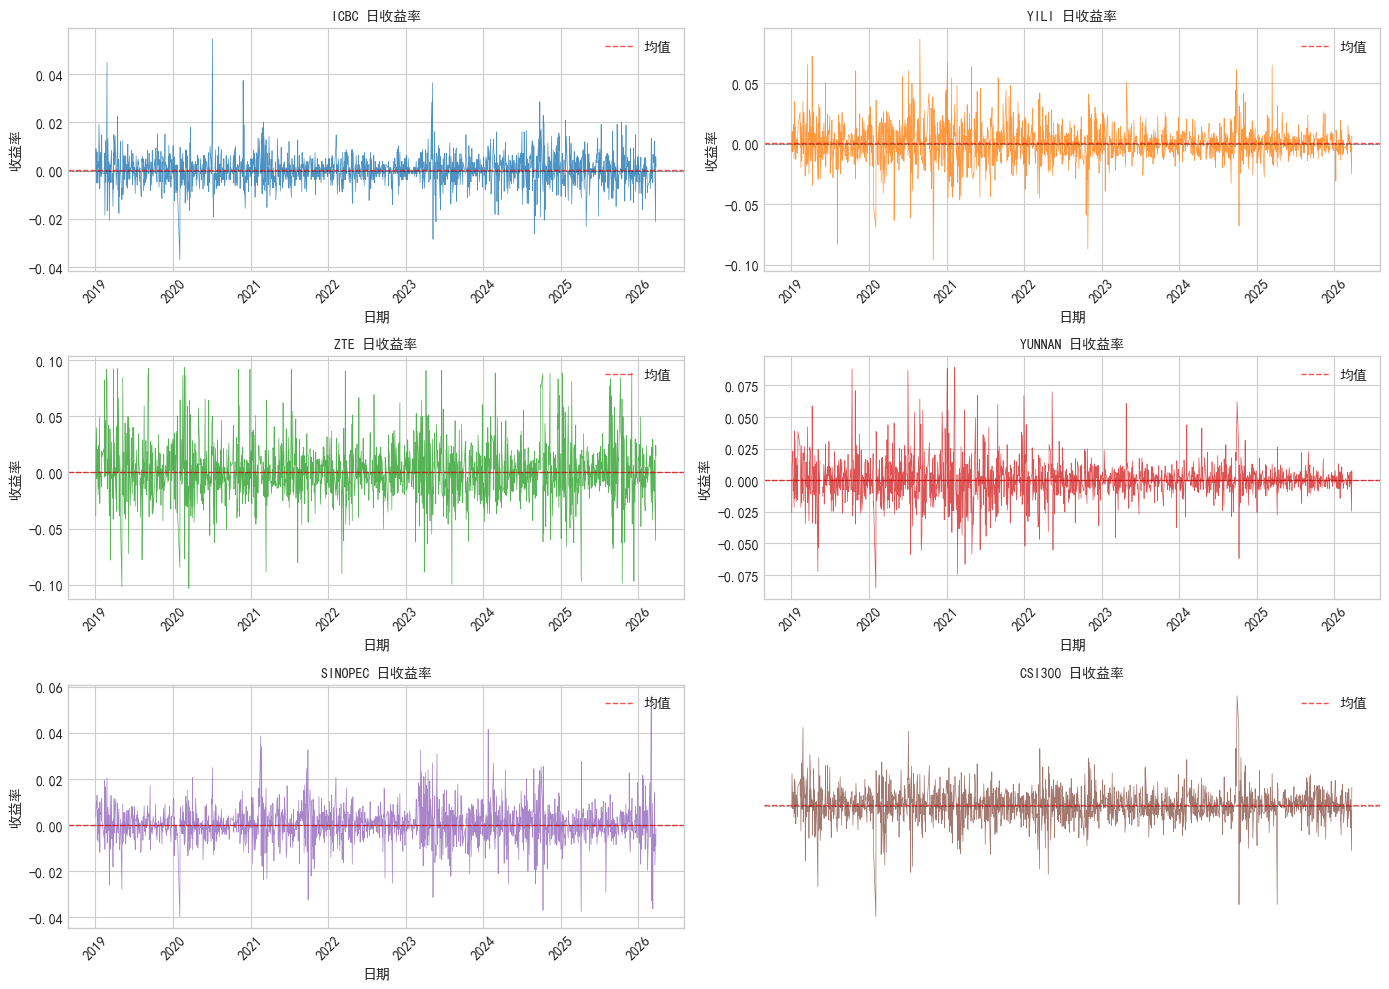

收益率时序图已保存至 output/returns_timeseries_faceted.png


In [14]:
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
import seaborn as sns
from scipy import stats

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘制5只股票和沪深300指数的收益率时序图（分面）
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, col in enumerate(return_df.columns):
    ax = axes[i]
    ax.plot(return_df.index, return_df[col], color=colors[i], linewidth=0.5, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axhline(y=return_df[col].mean(), color='red', linewidth=1, linestyle='--', alpha=0.7, label='均值')
    
    # ===================== 关键：每个中文都加 fontproperties =====================
    ax.set_title(f'{col} 日收益率', fontsize=12, fontproperties='SimHei')
    ax.set_xlabel('日期', fontsize=10, fontproperties='SimHei')
    ax.set_ylabel('收益率', fontsize=10, fontproperties='SimHei')
    ax.legend(loc='upper right', fontsize=8, prop={'family':'SimHei'})
    # ============================================================================
    
    ax.tick_params(axis='x', rotation=45)

# 隐藏多余的子图
axes[5].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'returns_timeseries_faceted.png'), dpi=150, bbox_inches='tight')
plt.show()

print('收益率时序图已保存至 output/returns_timeseries_faceted.png')

**结果解读**: 本代码生成了5只股票和沪深300指数的分面收益率时序图，每个子图展示一只股票的日收益率序列。红色虚线标注均值线，可观察波动聚集现象和时序分布特征。

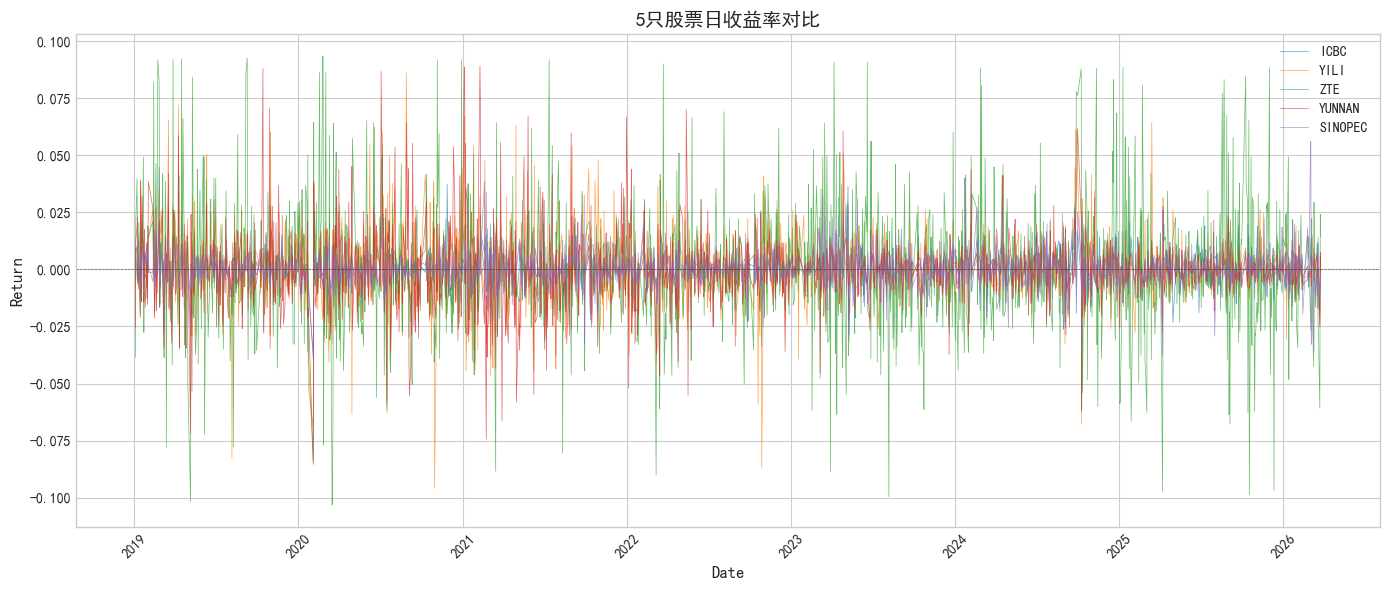

叠加收益率时序图已保存至 output/returns_timeseries_overlay.png


In [15]:
# 绘制叠加在一起的收益率时序图
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, col in enumerate(['ICBC', 'YILI', 'ZTE', 'YUNNAN', 'SINOPEC']):
    ax.plot(return_df.index, return_df[col], color=colors[i], linewidth=0.5, alpha=0.7, label=col)

ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_title('5只股票日收益率对比', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Return', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'returns_timeseries_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()

print('叠加收益率时序图已保存至 output/returns_timeseries_overlay.png')

**结果解读**: 本代码将5只股票的收益率叠加绘制在同一坐标系中，便于比较不同股票的走势差异、同步性以及波动聚集现象。

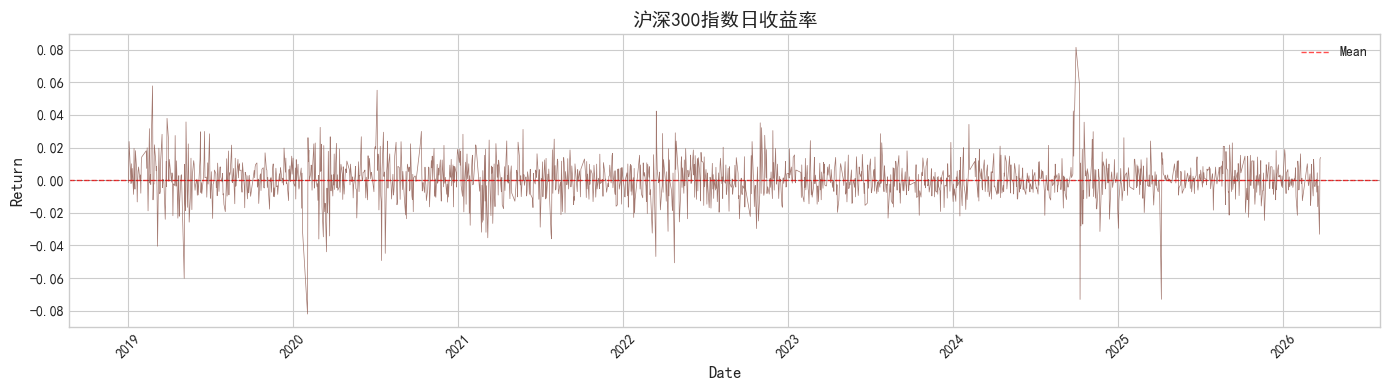

沪深300收益率时序图已保存至 output/CSI300_returns_timeseries.png


In [16]:
# 绘制沪深300指数收益率
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(return_df.index, return_df['CSI300'], color='#8c564b', linewidth=0.5, alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(y=return_df['CSI300'].mean(), color='red', linewidth=1, linestyle='--', alpha=0.7, label='Mean')
ax.set_title('沪深300指数日收益率', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Return', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'CSI300_returns_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

print('沪深300收益率时序图已保存至 output/CSI300_returns_timeseries.png')

**结果解读**: 本代码单独绘制沪深300指数收益率时序图，作为市场基准收益的代表。指数收益率反映A股市场整体表现，是后续CAPM分析的关键输入。

In [17]:
# 打印数据准备完成信息
print('='*80)
print('数据下载与预处理完成！')
print('='*80)
print(f'\n数据概览:')
print(f'  - 股票数量: 5只')
print(f'  - 指数: 沪深300')
print(f'  - 时间范围: {aligned_data.index.min().strftime("%Y-%m-%d")} 至 {aligned_data.index.max().strftime("%Y-%m-%d")}')
print(f'  - 有效交易日: {len(aligned_data)} 天')
print(f'\n输出文件:')
print(f'  - 原始数据: {DATA_RAW}/')
print(f'  - 清洗后数据: {DATA_CLEAN}/')
print(f'  - 图形输出: {OUTPUT}/')

数据下载与预处理完成！

数据概览:
  - 股票数量: 5只
  - 指数: 沪深300
  - 时间范围: 2019-01-03 至 2026-03-25
  - 有效交易日: 1739 天

输出文件:
  - 原始数据: data_raw/
  - 清洗后数据: data_clean/
  - 图形输出: output\Q1_data/


**结果解读**: 本代码打印数据准备完成信息，包括数据概览（5只股票、沪深300指数、时间范围、有效交易日数量）和输出文件位置。